# Network Conditions Impact Experiment

This notebook analyzes how different network environments (WiFi, Cellular, Poor Network) affect the visibility of device state signals in RTT data.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add simulator to path
sys.path.append(os.path.abspath("../simulator"))

from receipt_generator import ReceiptGenerator
from device_state_model import DeviceState, DeviceStateModel, DEFAULT_DEVICE_STATES
from network_delay_model import NetworkDelayModel, WIFI, CELLULAR, POOR_NETWORK

## 1. Setup Simulation

We compare the `ACTIVE` device state across three network profiles.

In [2]:
device_model = DeviceStateModel(state_profiles=DEFAULT_DEVICE_STATES, seed=42)

# Define the networks to test
networks = [WIFI, CELLULAR, POOR_NETWORK]

SAMPLES = 1000
target_state = DeviceState.ACTIVE

## 2. Generate Data

We simulate receipts for an **Active** user under different network conditions.

In [3]:
results = []

for net_profile in networks:
    # Re-instantiate generator with new network model
    network_model = NetworkDelayModel(profile=net_profile, seed=42)
    generator = ReceiptGenerator(device_model=device_model, network_model=network_model)
    
    for _ in range(SAMPLES):
        rtt = generator.generate_receipt(target_state)
        if rtt is not None:
            results.append({
                "Network": net_profile.name,
                "RTT": rtt
            })

df = pd.DataFrame(results)
print(df.groupby("Network")["RTT"].describe())

              count        mean         std         min         25%  \
Network                                                               
Cellular     1000.0  152.146345   40.555026  125.033062  129.238883   
PoorNetwork  1000.0  354.438405  194.115896  245.033062  255.370834   
WiFi         1000.0   52.282888    9.450653   45.025149   48.226188   

                    50%         75%          max  
Network                                           
Cellular     142.270055  158.003829   518.093350  
PoorNetwork  294.184537  348.687792  2027.215714  
WiFi          50.570190   54.064987   178.023660  


## 3. Visualization: The Masking Effect

Observe how the variance (width of the curve) increases with poorer networks. High network variance "masks" the subtle device-side processing delays.

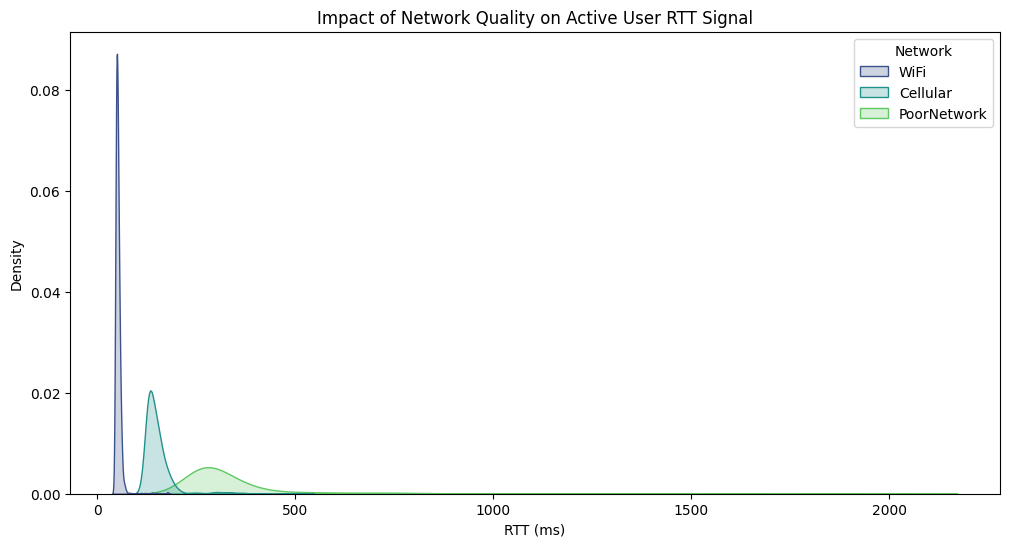

In [4]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="RTT", hue="Network", fill=True, common_norm=False, palette="viridis")
plt.title("Impact of Network Quality on Active User RTT Signal")
plt.xlabel("RTT (ms)")
plt.show()

## 4. Signal-to-Noise Discussion

Strictly speaking:
*   **Signal**: Device Processing Delay (Active ~5ms vs Idle ~40ms)
*   **Noise**: Network Jitter

On **WiFi**, simple thresholds work well.
On **Poor Networks**, the RTT distribution for an 'Active' user might overlap significantly with an 'Idle' user on WiFi, or even an 'Idle' user on the same network (due to the long tail).